<a href="https://colab.research.google.com/github/alisha-q/fraud-detection-shap/blob/main/notebooks/02_preprocessing_imbalance_handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/credit-card-fraud-detection-project"

Mounted at /content/drive


# Explainable Credit Card Fraud Detection - Preprocessing & Imbalance Handling

**Module:** 1 - Data Ingestion & Preprocessing (scaling, splitting, SMOTE)

**Goal:** Build the reusable preprocessing pipeline: scale `Time`/`Amount`, perform a
stratified 70/15/15 train/validation/test split, and apply SMOTE to the training set only
(Interim Report, Sections 4.2 and 5).

In [2]:
%pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


---
## 1) Load Dataset

In [3]:
DATA_PATH = os.path.join(f"{project_path}/data/creditcard.csv")
df = pd.read_csv(DATA_PATH)

FEATURE_COLUMNS = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
TARGET_COLUMN = "Class"

X = df[FEATURE_COLUMNS].values
y = df[TARGET_COLUMN].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Fraud count: {y.sum()} ({y.mean()*100:.4f}%)")

X shape: (284807, 30), y shape: (284807,)
Fraud count: 492 (0.1727%)


---
## 2) Stratified 70/15/15 Split

Stratification on `Class` is essential here: with only 492 fraud cases in the whole
dataset, a non-stratified split could easily leave the validation or test set with very
few (or wildly different proportions of) fraud examples.

In [4]:
def stratified_split(X, y, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, random_state=42):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=random_state, stratify=y
    )
    val_ratio_adjusted = val_ratio / (train_ratio + val_ratio)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_ratio_adjusted, random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(X, y)

print("Split sizes:")
for name, (Xs, ys) in {"Train": (X_train, y_train), "Val": (X_val, y_val), "Test": (X_test, y_test)}.items():
    print(f"  {name:5s}: {len(Xs):>7,} rows | fraud={int(ys.sum()):>4} ({ys.mean()*100:.4f}%)")

Split sizes:
  Train: 199,364 rows | fraud= 344 (0.1725%)
  Val  :  42,721 rows | fraud=  74 (0.1732%)
  Test :  42,722 rows | fraud=  74 (0.1732%)


---
## 3) Feature Scaling

`V1`-`V28` are already PCA-transformed and standardized by the dataset provider. Only
`Time` and `Amount` need scaling. The scaler is **fit on the training set only** and then
applied to validation/test to avoid data leakage.

In [5]:
def scale_time_amount(X_train, X_val, X_test, feature_columns=FEATURE_COLUMNS):
    scaler = StandardScaler()
    idx = [feature_columns.index(c) for c in ("Time", "Amount")]

    X_train = X_train.copy(); X_val = X_val.copy(); X_test = X_test.copy()
    X_train[:, idx] = scaler.fit_transform(X_train[:, idx])
    X_val[:, idx] = scaler.transform(X_val[:, idx])
    X_test[:, idx] = scaler.transform(X_test[:, idx])
    return X_train, X_val, X_test, scaler

X_train, X_val, X_test, scaler = scale_time_amount(X_train, X_val, X_test)
print("Scaled Time/Amount. Example scaled Amount values (train):", X_train[:5, FEATURE_COLUMNS.index('Amount')])

Scaled Time/Amount. Example scaled Amount values (train): [-0.05730613  1.96905545 -0.31497465 -0.27068787 -0.14177309]


---
## 4) Handling Class Imbalance: SMOTE + Class Weighting

Per the Interim Report (Section 2.3 / 4.2), we apply **SMOTE** (Chawla et al., 2002) to the
training set only, generating synthetic minority-class (fraud) examples by interpolating
between existing fraud cases in feature space — this is more effective than naive
duplication because it produces varied, representative synthetic samples rather than exact
copies. We target a moderate oversampling ratio (`sampling_strategy=0.5`, i.e. fraud becomes
50% of the majority count) rather than a full 1:1 balance, since over-aggressive SMOTE on an
extremely rare class can encourage overfitting to synthetic points. `class_weight='balanced'`
is used as a complementary algorithm-level safeguard on top of SMOTE for every model in
notebooks 03-04.

**Validation and test sets are left untouched** — they must reflect real-world class
proportions so evaluation metrics are meaningful.

In [6]:
print("Before SMOTE:", np.bincount(y_train))

smote = SMOTE(sampling_strategy=0.5, k_neighbors=5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE :", np.bincount(y_train_resampled))
print(f"Fraud went from {y_train.sum()} real examples to {y_train_resampled.sum()} "
      f"({y_train_resampled.sum() - y_train.sum()} synthetic)")

Before SMOTE: [199020    344]
After SMOTE : [199020  99510]
Fraud went from 344 real examples to 99510 (99166 synthetic)


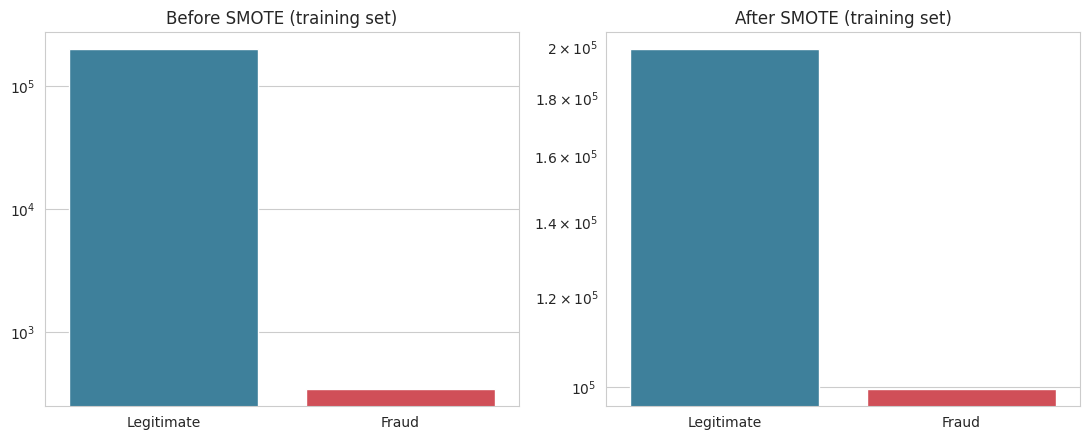

In [7]:
# Visualize class balance before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (labels, title) in zip(axes, [
        (np.bincount(y_train), "Before SMOTE (training set)"),
        (np.bincount(y_train_resampled.astype(int)), "After SMOTE (training set)")]):
    sns.barplot(x=["Legitimate","Fraud"], y=labels, hue=["Legitimate","Fraud"], legend=False,
                palette=["#2E86AB","#E63946"], ax=ax)
    ax.set_title(title)
    ax.set_yscale("log")
plt.tight_layout()
plt.savefig(f"{project_path}/results/smote_before_after.png", dpi=300)
plt.show()

---
## 5) Save Preprocessed Splits for Modeling Notebooks

In [8]:
import pickle

os.makedirs(f"{project_path}/models", exist_ok=True)
with open(f"{project_path}/models/preprocessed_splits.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train, "y_train": y_train,
        "X_train_resampled": X_train_resampled, "y_train_resampled": y_train_resampled,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "scaler": scaler,
        "feature_columns": FEATURE_COLUMNS,
    }, f)

print("Saved preprocessed_splits.pkl for reuse in notebooks 03-05")

Saved preprocessed_splits.pkl for reuse in notebooks 03-05


---
## Summary

- Implemented a reusable, leakage-safe scaling + stratified-splitting pipeline (also saved
  to `src/preprocessing.py`).
- Applied SMOTE to the training set only, growing the fraud class to 50% of the majority
  count via synthetic interpolation, while leaving validation/test at the real ~0.17% rate.
- Persisted all splits + the fitted scaler to `models/preprocessed_splits.pkl` for reuse.

**Next:** `03_baseline_logistic_regression.ipynb` — our interpretable baseline model.